**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Actividad: Clasificación con máquinas de vectores de soporte y árboles de decisión

## Objetivos

Mediante esta actividad se pretende que ponga en práctica la creación de modelos basados en máquinas de vectores de soporte y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Comprender el tratamiento de datos que hay que realizar para los modelos de clasificación.
- Entender y aplicar el algoritmo **Árboles de decisión** a un problema de clasificación.
- Entender y aplicar el algoritmo **Support Vector Machine** a un problema de clasificación.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/31/covertype

Este dataset ha sido generado para predecir el tipo de cubierta forestal únicamente a partir de variables cartográficas (sin datos de sensores remotos). El tipo de cubierta forestal real para una observación determinada (celda de 30 x 30 metros) se determinó a partir de los datos del Sistema de información de recursos (RIS) de la Región 2 del Servicio Forestal de EE. UU. (USFS). Las variables independientes se derivaron de datos obtenidos originalmente del Servicio Geológico de EE. UU. (USGS) y de datos del USFS. Los datos están en forma original (no escalados) y contienen columnas binarias (0 o 1) de datos para variables cualitativas independientes (áreas silvestres y tipos de suelo).
Para ampliar información sobre el dataset y su origen, recomendamos leer la descripción completa del dataset en el enlace del repositorio. l.

El objetivo de la clasificación será detectar el tipo de cubierta forestal.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Clasificación:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la **clasificación**.
    - Cómo utilizan las técnicas de **clasificación**, si realizan alguna adaptación de los algoritmos, esta deberá indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [12]:
# se carga el dataset
column_names = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways", "Hillshade_9am", "Hillshade_Noon",
    "Hillshade_3pm", "Horizontal_Distance_To_Fire_Points"
]

column_names += [f"Wilderness_Area_{i}" for i in range(1, 5)]
column_names += [f"Soil_Type_{i}" for i in range(1, 41)]

column_names += ["Cover_Type"]

df = pd.read_csv('./covertype/covtype.csv', header=None, names=column_names)

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


------------
¿Cuántas instancias de datos tiene el dataset?

In [ ]:
instances = df.shape[0]
print(f"El dataset tiene {instances} instancias de datos.")
df.info()

El dataset tiene 581012 instancias de datos.
<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area_1                   581012 non-null  int64
 11  Wilderness_Area_2 

## El dataset tiene 581.012 instancias

----------------
¿Cuántas variables continuas hay en el dataset?

In [15]:
continuous_vars = df.columns[:10]

print(f"Hay {len(continuous_vars)} variables continuas en el dataset.")
print("Lista de variables continuas:")
print(continuous_vars.tolist())

Hay 10 variables continuas en el dataset.
Lista de variables continuas:
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']


hay 10 variables continuas

-----------
¿Cuántas variables categóricas hay en el dataset? Indica las categorías.

hay X variables categóricas

In [16]:
categoric_vars = df.columns[10:-1]

print(f"Hay {len(categoric_vars)} variables categóricas (codificadas de forma binaria).")
print("Lista de categorías (Áreas silvestres y Tipos de suelo):")
print(categoric_vars.tolist())

Hay 44 variables categóricas (codificadas de forma binaria).
Lista de categorías (Áreas silvestres y Tipos de suelo):
['Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37', 'Soil_Type_38', 'Soil_Type_39', 'Soil_Type_40']


hay 44 variables continuas

-------------
¿Cómo es la distribución de etiquetas de clase en el dataset? Con estos datos, ¿podríamos decir que el dataset está balanceado?

            Instancias absolutas  Porcentaje (%)
Cover_Type                                      
2                         283301           48.76
1                         211840           36.46
3                          35754            6.15
7                          20510            3.53
6                          17367            2.99
5                           9493            1.63
4                           2747            0.47


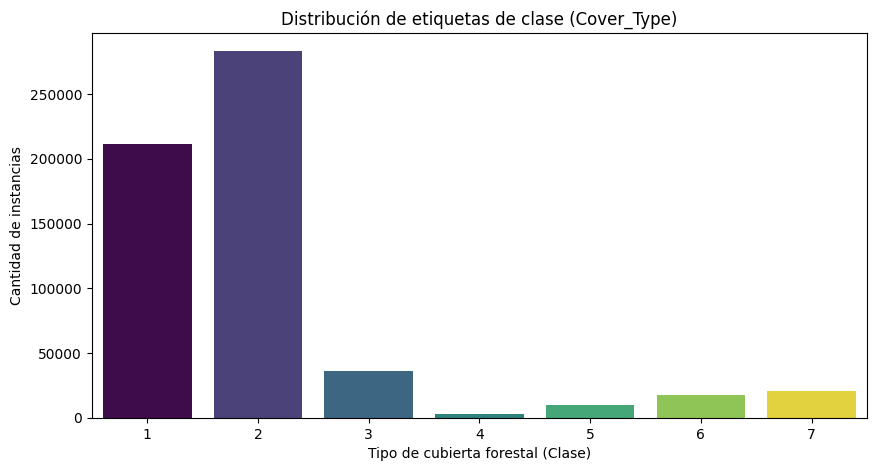

In [18]:
distribution = df['Cover_Type'].value_counts()
percentages = df['Cover_Type'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Instancias absolutas': distribution,
    'Porcentaje (%)': percentages.round(2)
})

print(class_summary)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Cover_Type', hue='Cover_Type', palette='viridis', legend=False)
plt.title('Distribución de etiquetas de clase (Cover_Type)')
plt.ylabel('Cantidad de instancias')
plt.xlabel('Tipo de cubierta forestal (Clase)')
plt.show()

## RESPUESTA

Podemos ver que el dataset no esta balanceado, hay una carga importante en las dos primeras clases y una representación mínima en la clase 4.

La distribución muestra una dominancia dominante de las clases 1 y 2 (Lodgepole Pine y Spruce/Fir) teniendo juntas una representación del 85% de las instancias en el conjunto de datos. Este desbalance debemos tenerlo en alta consideración para la aplicacion de algoritmos como SVM o Decission Trees porque pueden haber sesgos hacia las clases mayoritarias si no se aplican pesos para compensar.

-------------
¿Existen valores nulos o perdidos en el dataset?

In [19]:
total_nulls = df.isnull().sum().sum()

if total_nulls > 0:
    print(f"Se encontraron {total_nulls} valores nulos en total.")
    print("\nDetalle por columna:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("El dataset no contiene valores nulos o perdidos. La integridad de los datos está intacta.")

El dataset no contiene valores nulos o perdidos. La integridad de los datos está intacta.


## RESPUESTA

No he encontrado valores nulos

------------------

¿Existe alguna variable altamente correlacionada con la variable de clase?

_Nota: Para responder a esto, como es muy difícil ver la matriz de correlaciones, recomendamos filtrar aquellas correlaciones superiores al 0.80 con la variable de clase.

In [20]:
corr_matrix = df.corr()

corr_class = corr_matrix['Cover_Type'].abs()

high_corr = corr_class[corr_class > 0.80].drop('Cover_Type')

if high_corr.empty:
    print("No existen variables con una correlación de Pearson superior al 0.80 con Cover_Type.")
else:
    print("Variables altamente correlacionadas (>0.80):")
    print(high_corr)

print("\nTop 3 variables con mayor correlación lineal (aunque no superen el umbral de 0.80):")
print(corr_class.drop('Cover_Type').nlargest(3))

No existen variables con una correlación de Pearson superior al 0.80 con Cover_Type.

Top 3 variables con mayor correlación lineal (aunque no superen el umbral de 0.80):
Wilderness_Area_4    0.323200
Elevation            0.269554
Soil_Type_10         0.243876
Name: Cover_Type, dtype: float64


## RESPUESTA

No he encontrado variables on una correlacion de Pearson superior al 80% con Cover_Type

-------------

¿Qué tres variables del dataset consideras que pueden influenciar más en la clasificación de los datos?¿Qué pruebas harías para comprobar tus hipótesis? **Realiza dichas pruebas**.

In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

lineal_corr = df.corr()['Cover_Type'].abs().drop('Cover_Type').nlargest(3)
pearson_results = lineal_corr.round(4).to_dict()

df_sample = df.sample(frac=0.1, random_state=42)
X_test = df_sample.drop('Cover_Type', axis=1)
y_test = df_sample['Cover_Type']

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_test, y_test)

feature_importances = pd.Series(rf.feature_importances_, index=X_test.columns)
rf_results = feature_importances.nlargest(3).round(4).to_dict()

print("\n[MÉTRICA 1] Correlación Lineal (Pearson)")
print("-" * 65)
for variable, valor in pearson_results.items():
    print(f"  -> {variable.ljust(35)} : r = {valor:.4f}")

print("\n" + "=" * 65)
print("\n[MÉTRICA 2] Ganancia de Información (Random Forest)")
print("-" * 65)
for variable, valor in rf_results.items():
    percentage = valor * 100
    print(f"  -> {variable.ljust(35)} : {percentage:>5.2f}% de impacto espacial")


[MÉTRICA 1] Correlación Lineal (Pearson)
-----------------------------------------------------------------
  -> Wilderness_Area_4                   : r = 0.3232
  -> Elevation                           : r = 0.2696
  -> Soil_Type_10                        : r = 0.2439


[MÉTRICA 2] Ganancia de Información (Random Forest)
-----------------------------------------------------------------
  -> Elevation                           : 24.22% de impacto espacial
  -> Horizontal_Distance_To_Roadways     : 10.11% de impacto espacial
  -> Horizontal_Distance_To_Fire_Points  :  9.39% de impacto espacial


## RESPUESTA

Primero he realizado un analisis lineal para buscar la correlacion de Pearson, sin embargo he notado que ninguno de los valores supera el 35% por lo que no se sugiere una relacion estrictamente lineal.

Entonces he decidido implementar un RandomForest para encontrar las tres variables mas determinantes segun una capacidad predictiva no lineal.

Al final he encontrado como la mas alta a Elevation con un 24% por sobre un 10% y un 9% de Horizontal_Distance_To_Roadways y Horizontal_Distance_To_Fire_Points respectivamente. Esto puede mostrar que la relacion entre las variables cartogr'aficas y el tipo de cubierta forestal es no lineal y compleja por lo que usar arboles de decision y maquinas de soporte vectorial puede ser de hecho la mejor forma de abordar este problema.

-----------

### Clasificación

In [32]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)

**Árboles de decisión**

En esta parte de la actividad, hay que utilizar la librería https://scikit-learn.org/stable/modules/tree.html para resolver el problema de clasificación.

El algoritmo Decision Tree necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- max_depth
- min_samples_split
- min_samples_leaf
- max_features
- criterion
- ccp_alpha

**Indica qué son cada uno de estos hiperparámetros**

## RESPUESTA

Definimos un hiperparámetro como un valor que nos permite configurar el entrenamiento de un modelo para controlar el aprendizaje de este. Entonces, los hiperparámetros a diferencia de los parámetros aprendidos del modelo son externos y definidos por el usuario que entrena al modelo. En este caso, del árbol de decisión, nuestros hiperparámetros nos van a permitir controlar aspectos como la profundidad del arbol, el número mínimo de muestras para dividir los nodos o el criterio para decidir las divisiones.

### max_depth
Vamos a indicar la profundidad maxima que puede alcanzar el árbol.
### min_samples_split
Vamos a indicar el numero minimo de muestras que tiene que tener un nodo interno para poder dividirlo
### min_samples_leaf
Vamos a indicar el numero minimo de muestras que debe quedar en una hoja del arbol
### max_features
Vamos a definir la cantidad de variables predictores que vamos a considerar para buscar la mejor division en cada nodo.
### criterion
Vamos a definir la metrica a usar para medir la cantidad de una division. Por ejemplo podemos usar el criterio gini, entropy o log_loss.
### ccp_alpha
Vamos a definir el parametro usado para podar el arbol por complejidad de costo, o lo que conocemos por cost-complexity prunning

-------------------

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro _class_weight_

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

## RESPUESTA

Con el mecanismo class_weight iondicamos el ajuste que pemrite asignar el peso de importancia de cada una de las etiquetas de la clase segun la variale objetivo en la fase de entrenamiento.

Es util para corregir el sesgo predictivo cuando trabajamos con conjuntos de datos desbalanceados.

------------

Como primer paso para crear un clasificador con Árboles de Decision hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos.
¿Hace falta normalizar los datos?

## RESPUESTA

No, en árboles de decisión no hace falta normalizar ni estandarizar los datos.

-----------

Entrena un conjunto de modelos de árboles de decisión que utilicen todas las variables del dataset, con profundidades máximas de 5, 10, 20, 50 y 100 niveles.

El criterio para realizar las particiones debe ser Gini-index, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características evaluadas en cada partición deben ser todas.

In [38]:
from sklearn.tree import DecisionTreeClassifier

max_depth_values = [5, 10, 20, 50, 100]
criterion_val = 'gini'
min_samples_split_val = 10
min_samples_leaf_val = 2
max_features_val = None
ccp_alpha_val = 0.0

decision_trees = [
    DecisionTreeClassifier(
        criterion=criterion_val,
        max_depth=depth,
        min_samples_split=min_samples_split_val,
        min_samples_leaf=min_samples_leaf_val,
        max_features=max_features_val,
        ccp_alpha=ccp_alpha_val,
        random_state=42
    ) for depth in max_depth_values
]

In [39]:
print("Iniciando el entrenamiento de los modelos...")

for tree_model in decision_trees:
    tree_model.fit(X_train, y_train)
    print(f"Modelo entrenado - Profundidad máxima: {tree_model.max_depth}")

Iniciando el entrenamiento de los modelos...
Modelo entrenado - Profundidad máxima: 5
Modelo entrenado - Profundidad máxima: 10
Modelo entrenado - Profundidad máxima: 20
Modelo entrenado - Profundidad máxima: 50
Modelo entrenado - Profundidad máxima: 100


Visualiza la matriz de confusión del modelo entrenado con 20 niveles.

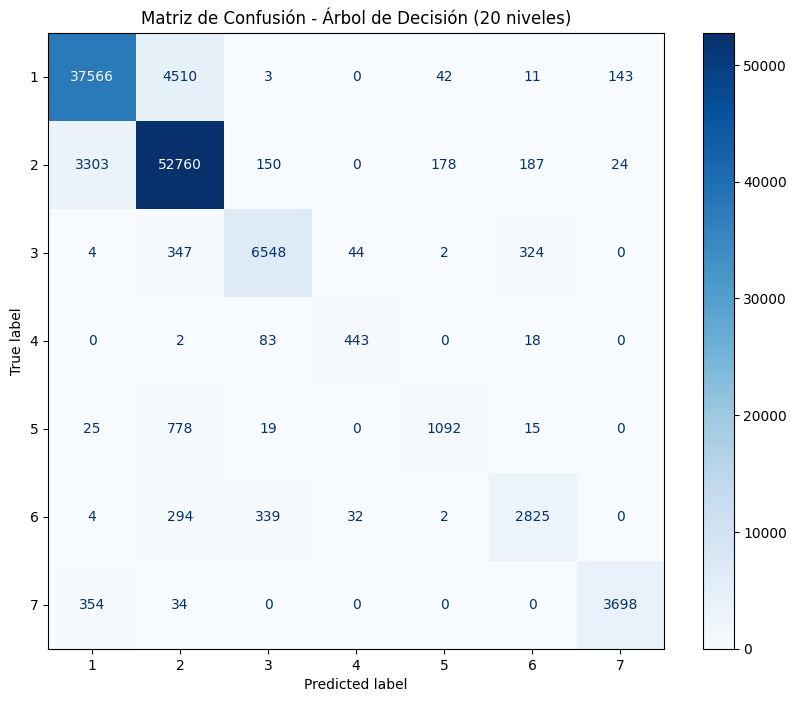

Ejemplos clasificados correctamente: 104932 de 116203

Reporte de clasificación por clase (20 niveles):
              precision    recall  f1-score   support

           1       0.91      0.89      0.90     42275
           2       0.90      0.93      0.91     56602
           3       0.92      0.90      0.91      7269
           4       0.85      0.81      0.83       546
           5       0.83      0.57      0.67      1929
           6       0.84      0.81      0.82      3496
           7       0.96      0.91      0.93      4086

    accuracy                           0.90    116203
   macro avg       0.89      0.83      0.85    116203
weighted avg       0.90      0.90      0.90    116203



In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model_depth_20 = decision_trees[2]
y_pred_20 = model_depth_20.predict(X_test)

cm_20 = confusion_matrix(y_test, y_pred_20)
disp_20 = ConfusionMatrixDisplay(confusion_matrix=cm_20, display_labels=model_depth_20.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp_20.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Árbol de Decisión (20 niveles)')
plt.show()

correct_predictions = (y_test == y_pred_20).sum()
total_predictions = len(y_test)

print(f"Ejemplos clasificados correctamente: {correct_predictions} de {total_predictions}")

report_20 = classification_report(y_test, y_pred_20)
print("\nReporte de clasificación por clase (20 niveles):")
print(report_20)

¿Cuántos ejemplos ha clasificado correctamente?

## RESPUESTA

He encontrado 104.932 ejemplos clasificados correctamente de un total de 116.203 instancias en el conjunto de pruebas. Esto es una precision global del 90%

----------------

Explica cómo funciona la clasificación **para cada una de las 7 clases**. ¿Hay alguna clase que clasifica mejor que otras?

## RESPUESTA

Si, hay dos clases dominantes, la 1 y la 2 con un 90 y un 91 porciento respectivamente. La clase 2 tiene el recall mas alto de todo el modelo con un 93$ indicando que el arbol es especialmente bueno detectando ese tipo de instancias gracias a la cantidad de datos de entrenamiento disponibles.

En el caso de las clases 3 y 7 a pesar de que el soporte era menor que en el caso de las clases 1  y 2, el modelo generaliza muy bien sus patrones logicos. En el caso de la clase 7 se tiene mas precision indicando un buen rendimiento en la prediccion de esta clase equivocandose muy poco.

Con respecto a las clases 4 y 6 vemos un rendimiento bastante bueno tambien pero con un descenso en la precision y la sensibilidad con un F1 score de 82 y 83%

Finalmente, con la clase 5 encontramos menos precision cayendo a un 57%, fallando en identificar el 43% de las instancias reales de esa clase.

--------------

¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precisión para el conjunto de datos de test?

_Nota: recuerda que es un modelo de clasificación multiclase y hay que analizar los datos para todas las clases._

In [ ]:
## PON AQUÍ TU CÓDIGO Y RESPUESTA

Selecciona el modelo que consideras que obtiene mejores resultados para los resultados de test. Explica por qué consideras que ese modelo es el que mejor resultados obtiene.

Visualiza la matriz de confusión de los datos de test de este modelo.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?


Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [ ]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

**Support Vector Machine**

In [ ]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

**Indica qué son cada uno de estos hiperparámetros**

_indica aquí tu respuesta_

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro decision_function_shape

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

_indica aquí tu respuesta_

Tenemos un dataset de más de medio millón de instancias, y para el objetivo de la actividad no hacen falta tantas. Por eso, antes de aplicar SVM vamos a reducir el número de instancias. SVM requiere una gran carga computacional y con ese volumen de instancias el tiempo requerido sería demasiado elevado.

In [ ]:
df = df.head(100000)

**Nota: recuerda revisar que esta manera de seleccionar un subconjunto de instancias nos deja un porcentaje similar de instancias de cada clase, esto es, nuestro dataset debe quedar balanceado. Si no fuera así, deberás cambiar la manera de seleccionar el subconjunto.**

In [ ]:
# Comprobamos si efectivamente tenemos un número similar de instancias para cada clase
df['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

In [ ]:
# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)


Como primer paso para crear un clasificador de SVM hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos. ¿Hace falta normalizar los datos? Justifica tu respuesta.

In [ ]:
## PON AQUÍ TU CÓDIGO SI CONSIDERAS QUE HAY QUE NORMALIZAR LOS DATOS

from sklearn.preprocessing import StandardScaler
from pandas import DataFrame


scaler = StandardScaler()

## COMPLETAR

Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes. Utiliza kernel radial, y gamma con valor *scale*.

In [ ]:
from sklearn.svm import SVC

C = {}
kernel = ''
gamma = ''

svc = [SVC(C=i, kernel=kernel, gamma=gamma) for i in C]
svc

In [ ]:
### PON AQUÍ TU CÓDIGO

In [ ]:
score

Después de hacer el entrenamiento, visualiza las matrices de confusión de los modelos entrenados.

In [ ]:
## PON AQUÍ TU CÓDIGO

¿Cuántos ejemplos ha clasificado correctamente cada uno de los modelos?

_indica aquí tu respuesta_

Selecciona el modelo que consideras que obtiene mejores resultados y realiza las predicciones con el conjunto de datos de test.

In [ ]:
## PON AQUÍ TU CÓDIGO

Visualiza la matriz de confusión de los datos de test para este modelo ganador.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?

In [ ]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [ ]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de clasificación?

### Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **clasificación** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la clasificación. **Técnicas de clasificación** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.